# HyperBench Tutorial 04: Metrics and Evaluation

This notebook focuses on evaluation in HyperBench.

The notation used throughout the tutorial series is:

- ground-truth hyperspectral image (GT HSI / HR HSI): `(H, W, C)`
- low-resolution hyperspectral image (LR HSI): `(H/r, W/r, C)`
- high-resolution multispectral image (HR MSI): `(H, W, c)`
- spectral response function (SRF): `(c, C)`
- point spread function (PSF): `(k, k)`

This notebook covers:

- computing the full metric set with `evaluate_metrics`
- understanding how each metric behaves under different prediction errors
- comparing several simple prediction variants against the same ground truth
- examining the effect of clipping before evaluation

## Related documentation

- `docs/index.md`
- `docs/metrics.md`
- `docs/quickstart.md`

## Imports

In [1]:
from pathlib import Path

import numpy as np

from hyperbench import (
    __version__,
    evaluate_metrics,
    load_hsi,
    normalize_image,
    print_data_stats,
    visualize_hsi,
)

print("HyperBench version:", __version__)

HyperBench version: 0.1.0


## Scene configuration

In [2]:
SCENE_PATH = Path("../data/DC_data.mat")
SCENE_KEY = "dc"

print("Scene path:", SCENE_PATH)
print("Scene key:", SCENE_KEY)

Scene path: ../data/DC_data.mat
Scene key: dc


## Load and normalize the ground-truth scene

All metric evaluations in this notebook are performed against the same normalized ground-truth hyperspectral image.

In [3]:
scene = load_hsi(SCENE_PATH, key=SCENE_KEY)
gt_hsi = normalize_image(scene)

print_data_stats(gt_hsi, name="Ground-truth HSI")
print("GT HSI shape (H, W, C):", gt_hsi.shape)

Ground-truth HSI type: <class 'numpy.ndarray'>
Ground-truth HSI dtype: float32
Ground-truth HSI shape (H, W, B): (1280, 307, 191)
Ground-truth HSI min: 0.0
Ground-truth HSI max: 1.0
Ground-truth HSI mean: 0.2233569175004959
Ground-truth HSI std: 0.24737973511219025
GT HSI shape (H, W, C): (1280, 307, 191)


## RGB view of the ground-truth HSI

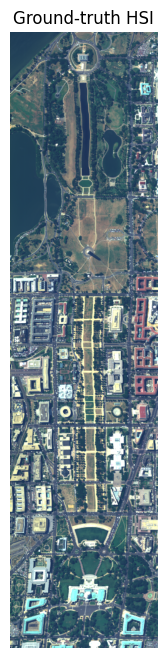

In [4]:
rgb_channels = (50, 35, 15)

visualize_hsi(gt_hsi, bands=rgb_channels, title="Ground-truth HSI")

## Build a set of simple prediction variants

To understand how the metrics respond, this notebook compares several deliberately simple prediction types:

- **Perfect prediction**: identical to the ground truth
- **Noisy prediction**: additive Gaussian noise
- **Biased prediction**: constant intensity offset
- **Compressed-range prediction**: contrast reduced toward the mean
- **Out-of-range prediction**: values intentionally pushed outside `[0, 1]`
- **Shuffled-channel prediction**: hyperspectral channel order disturbed

These are not model outputs. They are controlled perturbations used to study metric behavior.

In [5]:
rng = np.random.default_rng(42)

perfect_prediction = gt_hsi.copy()

noisy_prediction = np.clip(
    gt_hsi + rng.normal(loc=0.0, scale=0.03, size=gt_hsi.shape).astype(np.float32),
    0.0,
    1.0,
)

biased_prediction = np.clip(gt_hsi + 0.05, 0.0, 1.0)

scene_mean = float(gt_hsi.mean())
compressed_prediction = np.clip(
    scene_mean + 0.6 * (gt_hsi - scene_mean),
    0.0,
    1.0,
)

out_of_range_prediction = gt_hsi * 1.15 - 0.05

channel_order = np.arange(gt_hsi.shape[2])[::-1]
shuffled_channel_prediction = gt_hsi[:, :, channel_order]

predictions = {
    "Perfect": perfect_prediction,
    "Noisy": noisy_prediction,
    "Biased": biased_prediction,
    "CompressedRange": compressed_prediction,
    "OutOfRangeRaw": out_of_range_prediction,
    "ShuffledChannels": shuffled_channel_prediction,
}

## Inspect prediction statistics

In [6]:
for name, pred in predictions.items():
    print(f"--- {name} ---")
    print_data_stats(pred, name=name)
    print("Shape:", pred.shape)
    print()

--- Perfect ---
Perfect type: <class 'numpy.ndarray'>
Perfect dtype: float32
Perfect shape (H, W, B): (1280, 307, 191)
Perfect min: 0.0
Perfect max: 1.0
Perfect mean: 0.22335641086101532
Perfect std: 0.24737976491451263
Shape: (1280, 307, 191)

--- Noisy ---
Noisy type: <class 'numpy.ndarray'>
Noisy dtype: float32
Noisy shape (H, W, B): (1280, 307, 191)
Noisy min: 0.0
Noisy max: 1.0
Noisy mean: 0.2263304889202118
Noisy std: 0.245711088180542
Shape: (1280, 307, 191)

--- Biased ---
Biased type: <class 'numpy.ndarray'>
Biased dtype: float32
Biased shape (H, W, B): (1280, 307, 191)
Biased min: 0.05000000074505806
Biased max: 1.0
Biased mean: 0.27275943756103516
Biased std: 0.24555961787700653
Shape: (1280, 307, 191)

--- CompressedRange ---
CompressedRange type: <class 'numpy.ndarray'>
CompressedRange dtype: float32
CompressedRange shape (H, W, B): (1280, 307, 191)
CompressedRange min: 0.08934275805950165
CompressedRange max: 0.6893427968025208
CompressedRange mean: 0.22335712611675262
Co

## Visual comparison

The RGB composites below provide a quick sense of the perturbations before metric computation.

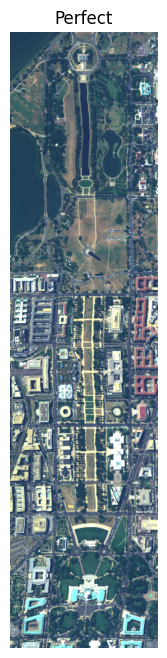

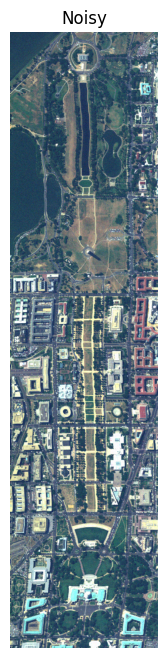

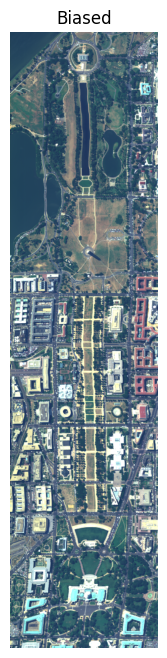

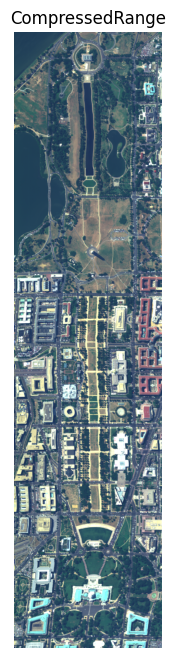

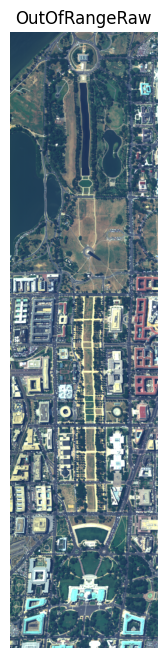

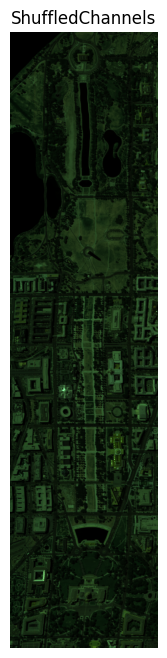

In [7]:
for name, pred in predictions.items():
    visualize_hsi(pred, bands=rgb_channels, title=name)

## Evaluate the full metric set

HyperBench exposes a single entry point:

```python
evaluate_metrics(gt_hsi, prediction)
```

which returns:

- RMSE
- PSNR
- SSIM
- UIQI
- ERGAS
- SAM

In [8]:
metric_table = {}

for name, pred in predictions.items():
    metric_table[name] = evaluate_metrics(gt_hsi, pred)

metric_table

{'Perfect': {'RMSE': 0.0,
  'PSNR': inf,
  'SSIM': 1.0,
  'UIQI': 1.0,
  'ERGAS': 0.0,
  'SAM': 0.008505243808031082},
 'Noisy': {'RMSE': 0.027201801369648556,
  'PSNR': 31.3284886753776,
  'SSIM': 0.7538494248934516,
  'UIQI': 0.7451049537244505,
  'ERGAS': 89.4365474710226,
  'SAM': 5.555115699768066},
 'Biased': {'RMSE': 0.049682876073026606,
  'PSNR': 26.086639371308426,
  'SSIM': 0.7139829016321887,
  'UIQI': 0.6406861591857107,
  'ERGAS': 209.06303963037257,
  'SAM': 6.656985759735107},
 'CompressedRange': {'RMSE': 0.09895187994833624,
  'PSNR': 20.089601496299046,
  'SSIM': 0.6112820055326365,
  'UIQI': 0.5942002862889593,
  'ERGAS': 369.94035491030866,
  'SAM': 15.427318572998047},
 'OutOfRangeRaw': {'RMSE': 0.04060862310304986,
  'PSNR': 31.840606240274663,
  'SSIM': 0.825774018463459,
  'UIQI': 0.6644521733773225,
  'ERGAS': 207.68282639811716,
  'SAM': 7.42945671081543},
 'ShuffledChannels': {'RMSE': 0.42879688974997265,
  'PSNR': 7.355528848226288,
  'SSIM': 0.1124658079031

## Print the metrics clearly

In [9]:
for name, metric_values in metric_table.items():
    print(f"=== {name} ===")
    for metric_name, value in metric_values.items():
        print(f"{metric_name:>5}: {value}")
    print()

=== Perfect ===
 RMSE: 0.0
 PSNR: inf
 SSIM: 1.0
 UIQI: 1.0
ERGAS: 0.0
  SAM: 0.008505243808031082

=== Noisy ===
 RMSE: 0.027201801369648556
 PSNR: 31.3284886753776
 SSIM: 0.7538494248934516
 UIQI: 0.7451049537244505
ERGAS: 89.4365474710226
  SAM: 5.555115699768066

=== Biased ===
 RMSE: 0.049682876073026606
 PSNR: 26.086639371308426
 SSIM: 0.7139829016321887
 UIQI: 0.6406861591857107
ERGAS: 209.06303963037257
  SAM: 6.656985759735107

=== CompressedRange ===
 RMSE: 0.09895187994833624
 PSNR: 20.089601496299046
 SSIM: 0.6112820055326365
 UIQI: 0.5942002862889593
ERGAS: 369.94035491030866
  SAM: 15.427318572998047

=== OutOfRangeRaw ===
 RMSE: 0.04060862310304986
 PSNR: 31.840606240274663
 SSIM: 0.825774018463459
 UIQI: 0.6644521733773225
ERGAS: 207.68282639811716
  SAM: 7.42945671081543

=== ShuffledChannels ===
 RMSE: 0.42879688974997265
 PSNR: 7.355528848226288
 SSIM: 0.1124658079031767
 UIQI: 0.1079383218302876
ERGAS: 2265.8279728020752
  SAM: 81.75100708007812



## Compare the out-of-range case before and after clipping

HyperBench supports clipping predictions before evaluation so that the prediction range is consistent with the normalized ground truth.

This section isolates that effect explicitly.

In [10]:
out_of_range_clipped = np.clip(out_of_range_prediction, 0.0, 1.0)

print("Raw out-of-range prediction:")
print_data_stats(out_of_range_prediction, name="OutOfRangeRaw")
print("Shape:", out_of_range_prediction.shape)

print()
print("Clipped out-of-range prediction:")
print_data_stats(out_of_range_clipped, name="OutOfRangeClipped")
print("Shape:", out_of_range_clipped.shape)

Raw out-of-range prediction:
OutOfRangeRaw type: <class 'numpy.ndarray'>
OutOfRangeRaw dtype: float32
OutOfRangeRaw shape (H, W, B): (1280, 307, 191)
OutOfRangeRaw min: -0.05000000074505806
OutOfRangeRaw max: 1.100000023841858
OutOfRangeRaw mean: 0.20685985684394836
OutOfRangeRaw std: 0.2844868302345276
Shape: (1280, 307, 191)

Clipped out-of-range prediction:
OutOfRangeClipped type: <class 'numpy.ndarray'>
OutOfRangeClipped dtype: float32
OutOfRangeClipped shape (H, W, B): (1280, 307, 191)
OutOfRangeClipped min: 0.0
OutOfRangeClipped max: 1.0
OutOfRangeClipped mean: 0.22017228603363037
OutOfRangeClipped std: 0.26790493726730347
Shape: (1280, 307, 191)


In [11]:
raw_metrics = evaluate_metrics(gt_hsi, out_of_range_prediction)
clipped_metrics = evaluate_metrics(gt_hsi, out_of_range_clipped)

print("=== Out-of-range prediction (raw) ===")
for metric_name, value in raw_metrics.items():
    print(f"{metric_name:>5}: {value}")

print()
print("=== Out-of-range prediction (clipped) ===")
for metric_name, value in clipped_metrics.items():
    print(f"{metric_name:>5}: {value}")

=== Out-of-range prediction (raw) ===
 RMSE: 0.04060862310304986
 PSNR: 31.840606240274663
 SSIM: 0.825774018463459
 UIQI: 0.6644521733773225
ERGAS: 207.68282639811716
  SAM: 7.42945671081543

=== Out-of-range prediction (clipped) ===
 RMSE: 0.025836937395520218
 PSNR: 31.840606240274663
 SSIM: 0.825774018463459
 UIQI: 0.5878273632398333
ERGAS: 18.90458303132779
  SAM: 4.0409955978393555


## Interpreting the metrics

The metric set used in HyperBench combines spatial and spectral views of reconstruction quality.

A useful rule of thumb is:

- **RMSE**: lower is better
- **PSNR**: higher is better
- **SSIM**: higher is better
- **UIQI**: higher is better
- **ERGAS**: lower is better
- **SAM**: lower is better

The examples above illustrate that different errors affect different metrics in different ways:

- additive noise usually hurts RMSE and PSNR quickly
- range compression changes contrast and affects structural measures
- shuffled hyperspectral channels strongly damage spectral consistency and usually worsen SAM substantially
- clipping can improve evaluation when a prediction only fails by leaving the expected numeric range

## A compact comparison table

In [12]:
metric_names = ["RMSE", "PSNR", "SSIM", "UIQI", "ERGAS", "SAM"]

header = ["Case"] + metric_names
rows = []

for name, metric_values in metric_table.items():
    row = [name] + [f"{metric_values[m]:.6f}" for m in metric_names]
    rows.append(row)

column_widths = [max(len(str(x)) for x in col) for col in zip(header, *rows)]

def format_row(row):
    return " | ".join(str(item).ljust(width) for item, width in zip(row, column_widths))

print(format_row(header))
print("-+-".join("-" * width for width in column_widths))
for row in rows:
    print(format_row(row))

Case             | RMSE     | PSNR      | SSIM     | UIQI     | ERGAS       | SAM      
-----------------+----------+-----------+----------+----------+-------------+----------
Perfect          | 0.000000 | inf       | 1.000000 | 1.000000 | 0.000000    | 0.008505 
Noisy            | 0.027202 | 31.328489 | 0.753849 | 0.745105 | 89.436547   | 5.555116 
Biased           | 0.049683 | 26.086639 | 0.713983 | 0.640686 | 209.063040  | 6.656986 
CompressedRange  | 0.098952 | 20.089601 | 0.611282 | 0.594200 | 369.940355  | 15.427319
OutOfRangeRaw    | 0.040609 | 31.840606 | 0.825774 | 0.664452 | 207.682826  | 7.429457 
ShuffledChannels | 0.428797 | 7.355529  | 0.112466 | 0.107938 | 2265.827973 | 81.751007


## Summary

This notebook examined the evaluation layer of HyperBench by comparing several controlled prediction variants against the same ground-truth scene.

It showed:

- how to compute the full metric set
- how different kinds of prediction errors influence different metrics
- why clipping matters for normalized evaluation
- how to read the metric outputs in context

These ideas carry directly into real benchmark results produced by models wrapped inside HyperBench.